In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ============================================
# STEP 1: Load Data
# ============================================
df = pd.read_csv('Supplement_Sales_Weekly_Expanded.csv')

print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"Total Rows: {len(df)}")
print(f"Unique Products: {df['Product Name'].nunique()}")
print(f"Unique Categories: {df['Category'].nunique()}")
print(f"\nColumns: {df.columns.tolist()}")


DATASET OVERVIEW
Total Rows: 4384
Unique Products: 16
Unique Categories: 10

Columns: ['Date', 'Product Name', 'Category', 'Inventory Level', 'Units Sold', 'Unit Order', 'Actual Price', 'Unit Price', 'Discount', 'Total Price', 'Revenue', 'Region', 'Holiday/Promotion']


In [4]:
# STEP 2: Data Preprocessing
# ============================================
# Convert Date
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
df = df.sort_values('Date').reset_index(drop=True)

# Convert numeric columns
numeric_columns = ['Inventory Level', 'Units Sold', 'Unit Order', 
                   'Actual Price', 'Unit Price', 'Discount', 
                   'Total Price', 'Revenue', 'Holiday/Promotion']

for col in numeric_columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.replace(',', '').str.strip()
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna().reset_index(drop=True)

# Encode categorical
le_product = LabelEncoder()
le_category = LabelEncoder()
le_region = LabelEncoder()

df['Product_Encoded'] = le_product.fit_transform(df['Product Name'])
df['Category_Encoded'] = le_category.fit_transform(df['Category'])
df['Region_Encoded'] = le_region.fit_transform(df['Region'])

# Extract time features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week
df['Quarter'] = df['Date'].dt.quarter
df['DayOfYear'] = df['Date'].dt.dayofyear

print(f"\n✅ Data preprocessed: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")


✅ Data preprocessed: (4384, 21)
Date range: 2020-01-06 00:00:00 to 2025-03-31 00:00:00


In [5]:
# STEP 3: Create Lag Features
# ============================================
def create_lag_features(df, target_col='Units Sold', lags=[1, 2, 3, 4]):
    df_lag = df.copy()
    df_lag = df_lag.sort_values(['Product Name', 'Category', 'Date']).reset_index(drop=True)
    
    for lag in lags:
        df_lag[f'Units_Sold_Lag_{lag}'] = df_lag.groupby(['Product Name', 'Category'])[target_col].shift(lag)
    
    df_lag['Units_Sold_Rolling_Mean_4'] = df_lag.groupby(['Product Name', 'Category'])[target_col].transform(
        lambda x: x.rolling(window=4, min_periods=1).mean()
    )
    df_lag['Units_Sold_Rolling_Std_4'] = df_lag.groupby(['Product Name', 'Category'])[target_col].transform(
        lambda x: x.rolling(window=4, min_periods=1).std()
    )
    df_lag['Units_Sold_Rolling_Std_4'] = df_lag['Units_Sold_Rolling_Std_4'].fillna(0)
    
    return df_lag

df = create_lag_features(df)
df = df.dropna().reset_index(drop=True)

print(f"✅ Lag features created: {df.shape}")


✅ Lag features created: (4320, 27)


In [6]:
# STEP 4: Remove Leakage Features
# ============================================
# ❌ REMOVE: Total Price, Revenue, Unit Order (they leak target)
# ✅ KEEP: Only features available BEFORE Units Sold happens

feature_cols = [
    'Product_Encoded', 'Category_Encoded', 'Region_Encoded',
    'Inventory Level',
    'Actual Price', 'Unit Price', 'Discount',
    'Holiday/Promotion',
    'Year', 'Month', 'Week', 'Quarter', 'DayOfYear',
    'Units_Sold_Lag_1', 'Units_Sold_Lag_2', 'Units_Sold_Lag_3', 'Units_Sold_Lag_4',
    'Units_Sold_Rolling_Mean_4', 'Units_Sold_Rolling_Std_4'
]

target_col = 'Units Sold'

print("\n✅ Features (NO LEAKAGE):")
print(feature_cols)


✅ Features (NO LEAKAGE):
['Product_Encoded', 'Category_Encoded', 'Region_Encoded', 'Inventory Level', 'Actual Price', 'Unit Price', 'Discount', 'Holiday/Promotion', 'Year', 'Month', 'Week', 'Quarter', 'DayOfYear', 'Units_Sold_Lag_1', 'Units_Sold_Lag_2', 'Units_Sold_Lag_3', 'Units_Sold_Lag_4', 'Units_Sold_Rolling_Mean_4', 'Units_Sold_Rolling_Std_4']


In [7]:
# STEP 5: Time-Based Train/Test Split
# ============================================
# Split by date (last 20% for testing)
unique_dates = sorted(df['Date'].unique())
split_date = unique_dates[int(len(unique_dates) * 0.8)]

train_df = df[df['Date'] < split_date]
test_df = df[df['Date'] >= split_date]

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test = test_df[feature_cols]
y_test = test_df[target_col]

print("\n" + "="*60)
print("TRAIN/TEST SPLIT (TIME-BASED)")
print("="*60)
print(f"Split date: {split_date}")
print(f"Training: {X_train.shape[0]} rows ({train_df['Date'].min()} to {train_df['Date'].max()})")
print(f"Testing:  {X_test.shape[0]} rows ({test_df['Date'].min()} to {test_df['Date'].max()})")


TRAIN/TEST SPLIT (TIME-BASED)
Split date: 2024-03-25 00:00:00
Training: 3456 rows (2020-02-03 00:00:00 to 2024-03-18 00:00:00)
Testing:  864 rows (2024-03-25 00:00:00 to 2025-03-31 00:00:00)


In [17]:
# STEP 6: Train Model (Improved Tuning)
# ============================================

model = xgb.XGBRegressor(
    n_estimators=300,          # more trees → smoother learning
    learning_rate=0.05,        # smaller LR → less overfitting
    max_depth=4,               # shallower trees → better generalization
    min_child_weight=3,        # avoids overly specific splits
    subsample=0.8,             # randomly sample rows (prevents overfit)
    colsample_bytree=0.7,      # randomly sample columns (prevents overfit)
    reg_alpha=1,               # L1 regularization
    reg_lambda=1.5,            # L2 regularization
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

print("\n🚀 Training tuned model (better generalization)...")
model.fit(X_train, y_train)
print("✅ Training completed with tuned parameters!")



🚀 Training tuned model (better generalization)...
✅ Training completed with tuned parameters!


In [21]:
# STEP 7: Evaluate
# ============================================
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

train_mae = mean_absolute_error(y_train, y_pred_train)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
train_mse = mean_squared_error(y_train, y_pred_train)
train_r2 = r2_score(y_train, y_pred_train)

test_mae = mean_absolute_error(y_test, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_mse = mean_squared_error(y_test, y_pred_test)
test_r2 = r2_score(y_test, y_pred_test)

print("\n" + "="*60)
print("MODEL PERFORMANCE (CORRECTED - NO LEAKAGE)")
print("="*60)
print(f"\nTraining Set:")
print(f"  MAE:  {train_mae:.2f} units")
print(f"  RMSE: {train_rmse:.2f} units")
print(f"  MSE:  {train_mse:.2f} units")
print(f"  R²:   {train_r2:.4f}")

print(f"\nTest Set:")
print(f"  MAE:  {test_mae:.2f} units")
print(f"  RMSE: {test_rmse:.2f} units")
print(f"  MSE:  {test_mse:.2f} units")
print(f"  R²:   {test_r2:.4f}")

print(f"\n📊 R² Gap: {abs(train_r2 - test_r2):.4f}")




MODEL PERFORMANCE (CORRECTED - NO LEAKAGE)

Training Set:
  MAE:  1.62 units
  RMSE: 2.00 units
  MSE:  4.02 units
  R²:   0.9739

Test Set:
  MAE:  2.64 units
  RMSE: 3.47 units
  MSE:  12.03 units
  R²:   0.9205

📊 R² Gap: 0.0535


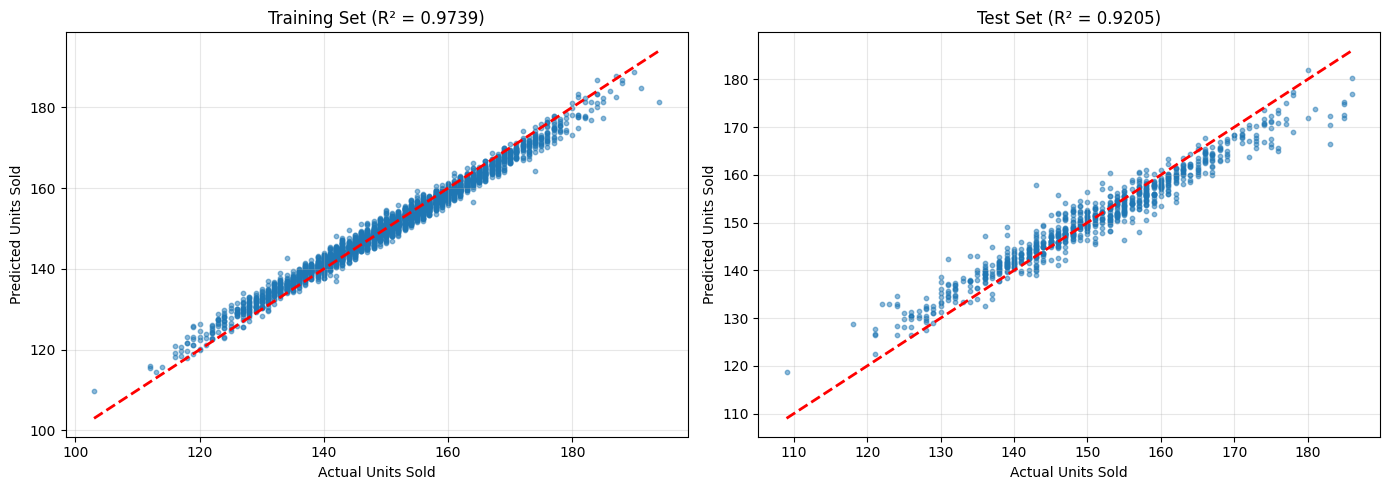

✅ Saved: graphs/actual_vs_predicted_corrected.png


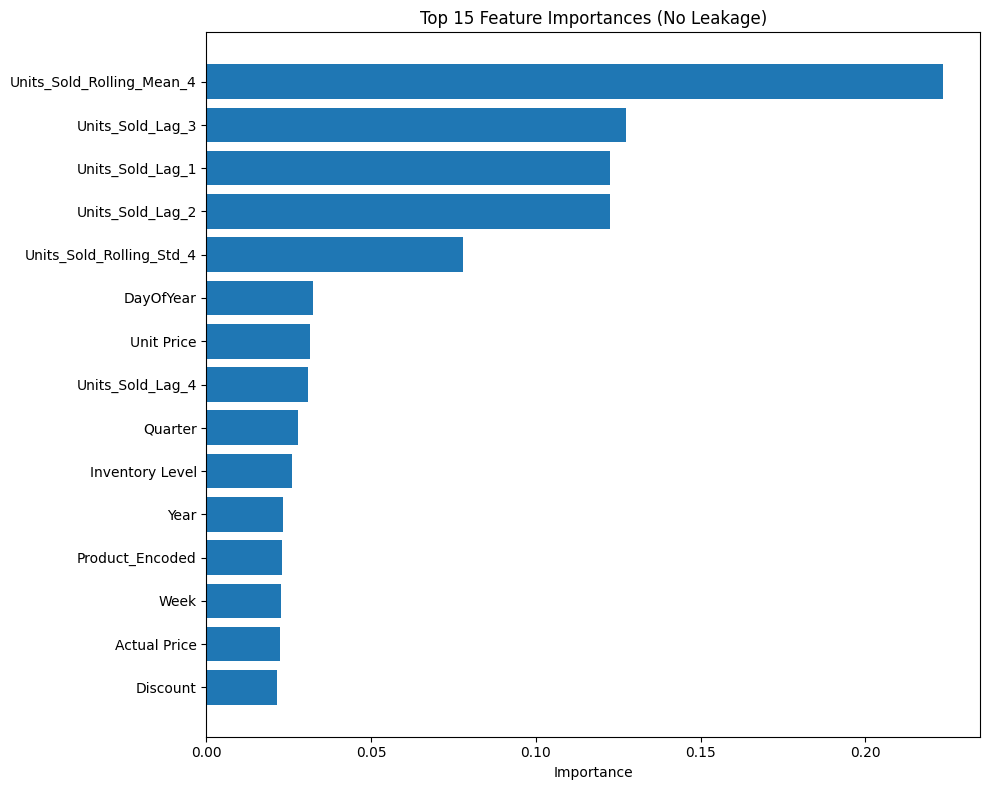

✅ Saved: graphs/feature_importance_corrected.png


In [19]:
# STEP 8: Save Visualizations
# ============================================
os.makedirs('graphs', exist_ok=True)

# Plot 1: Actual vs Predicted
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_train, y_pred_train, alpha=0.5, s=10)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel('Actual Units Sold')
plt.ylabel('Predicted Units Sold')
plt.title(f'Training Set (R² = {train_r2:.4f})')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_test, alpha=0.5, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Units Sold')
plt.ylabel('Predicted Units Sold')
plt.title(f'Test Set (R² = {test_r2:.4f})')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('graphs/actual_vs_predicted_corrected.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: graphs/actual_vs_predicted_corrected.png")

# Plot 2: Feature Importance
plt.figure(figsize=(10, 8))
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.barh(feature_importance['Feature'][:15], feature_importance['Importance'][:15])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances (No Leakage)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('graphs/feature_importance_corrected.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: graphs/feature_importance_corrected.png")


In [20]:
# STEP 9: Save Model
# ============================================
os.makedirs('models', exist_ok=True)

model.save_model('models/xgboost_stock_predictor.json')
with open('models/xgboost_stock_predictor.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('models/label_encoders.pkl', 'wb') as f:
    pickle.dump({
        'product': le_product,
        'category': le_category,
        'region': le_region
    }, f)

with open('models/feature_columns.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

df.to_csv('models/processed_data.csv', index=False)

print("\n✅ Model saved in 'models' folder")



✅ Model saved in 'models' folder
